# Improving GRPO for Reinforcement Learning
## Tracking GRPO Performance Metrics
### Executing a GRPO Training Run

In [2]:
import torch
from mi.gpu import get_device
from mi.lm.model_loader import load_model_and_tokenizer
from mi.dataloaders.math import load_math_train

device = get_device()
model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)
model.to(device)
math_train = load_math_train()
torch.manual_seed(0)

Using Apple Silicon GPU (MPS)
qwen3-0.6B-base.pth: 100% (1433 MiB / 1433 MiB)


In [4]:
# Copied from 06/rl.ipynb

import time
from pathlib import Path

def train_rlvr_grpo(
        model,
        tokenizer,
        math_data,
        device,
        steps=None,
        num_rollouts=2,
        max_new_tokens=256,
        temperature=0.8,
        top_p=0.9,
        lr=1e-5,
        checkpoint_every=50,
        checkpoint_dir=".",
        csv_log_path=None,
):
    if steps is None:
        steps = len(math_data)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    model.train()
    current_step = 0

    if csv_log_path is None:
        timestamp = time.strftime("%Y%m%d-%H%M%S")
        csv_log_path = f"train_rlvr_grpo_{timestamp}.csv"

    csv_log_path = Path(csv_log_path)

    try:
        for step in range(steps):
            optimizer.zero_grad()

            current_step = step + 1
            example = math_data[step % len(math_data)]

            stats = compute_grpo_loss(
                model=model,
                tokenizer=tokenizer,
                example=example,
                device=device,
                num_rollouts=num_rollouts,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_p=top_p,
            )

            stats["loss_tensor"].backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            reward_avg = torch.tensor(stats["rewards"]).mean().item()
            step_tokens = sum(
                sample["gen_len"] for sample in stats["samples"]
            )
            avg_response_len = (
                step_tokens / len(stats["samples"]) if stats["samples"] else 0.0
            )
            append_csv_metrics(
                csv_log_path, current_step, steps,
                stats["loss"], reward_avg, avg_response_len,
            )
            print(
                f"[Step {current_step}/{steps}] "
                f"loss={stats['loss']:.4f} "
                f"reward_avg={reward_avg:.3f} "
                f"avg_response_len={avg_response_len:.1f}"
            )

            if checkpoint_every and current_step % checkpoint_every == 0:
                ckpt_path = save_checkpoint(
                    model=model,
                    checkpoint_dir=checkpoint_dir,
                    step=current_step,
                )
                print(f"Saved checkpoint at {ckpt_path}")
    except KeyboardInterrupt:
        ckpt_path = save_checkpoint(
            model=model,
            checkpoint_dir=checkpoint_dir,
            step=max(1, current_step),
            suffix="interrupt",
        )
        print(f"\nKeyboardInterrupt. Saved checkpoint at {ckpt_path}")
        return model

    return model


def save_checkpoint(model, checkpoint_dir, step, suffix=""):
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    suffix = f"-{suffix}" if suffix else ""
    ckpt_path = (
        checkpoint_dir /
        f"qwen3-0.6B-rlvr-grpo-step{step:05d}{suffix}.pth"
    )
    torch.save(model.state_dict(), ckpt_path)
    return ckpt_path


def append_csv_metrics(
        csv_log_path,
        step_idx,
        total_steps,
        loss,
        reward_avg,
        avg_response_len,
):
    if not csv_log_path.exists():
        csv_log_path.write_text(
            "step,total_steps,loss,reward_avg,avg_response_len\n",
            encoding="utf-8",
        )

    with csv_log_path.open("a", encoding="utf-8") as f:
        f.write(
            f"{step_idx},{total_steps},{loss:6f},{reward_avg:6f},{avg_response_len:6f}\n"
        )


In [ ]:
# Manual trainin
# train_rlvr_grpo(
#     model=model,
#     tokenizer=tokenizer,
#     math_data=math_train,
#     device=device,
#     steps=50,
#     num_rollouts=4,
#     max_new_tokens=512,
#     temperature=0.8,
#     top_p=0.9,
#     lr=1e-5,
#     checkpoint_every=5,
#     checkpoint_dir=".",
# )

In [5]:
# Code from the book to shortcut and download from GitHub

from pathlib import Path
import requests

def download_from_github(rel_path, out=None):
    github_raw_base = (  #1
        "https://raw.githubusercontent.com/rasbt/"
        "reasoning-from-scratch/refs/heads/main/"
    )

    rel_path = Path(rel_path)

    out = Path(out) if out is not None else Path(rel_path.name)#2

    if out.exists():  #3
        size_kb = out.stat().st_size / 1e3
        print(f"{out}: {size_kb:.1f} KB (cached)")
        return out


    r = requests.get(github_raw_base + rel_path.as_posix())#4
    r.raise_for_status()

    out.write_bytes(r.content)
    size_kb = out.stat().st_size / 1e3
    print(f"{out}: {size_kb:.1f} KB")


In [6]:
download_from_github(
    "ch06/02_rlvr_grpo_scripts_intro/rlvr_grpo_original_no_kl.py"
)

rlvr_grpo_original_no_kl.py: 15.6 KB


In [7]:
!uv run rlvr_grpo_original_no_kl.py --steps 500 --max_new_tokens 1024 --show_eta

Using Apple Silicon GPU (MPS)
qwen3-0.6B-base.pth: 100% (1433 MiB / 1433 MiB)
[Step 1/500] loss=-0.0000 reward_avg=0.000 tok/sec=35.5 avg_resp_len=264.5 | ETA: 8h 16m 01s
[Step 2/500] loss=-0.0000 reward_avg=0.000 tok/sec=13.4 avg_resp_len=7.9 | ETA: 4h 27m 00s
[Step 3/500] loss=9.0741 reward_avg=0.250 tok/sec=31.9 avg_resp_len=34.9 | ETA: 3h 21m 49s
[Step 4/500] loss=32.7442 reward_avg=0.375 tok/sec=35.0 avg_resp_len=52.1 | ETA: 2h 55m 41s
[Step 5/500] loss=2.4093 reward_avg=0.500 tok/sec=39.6 avg_resp_len=412.5 | ETA: 4h 37m 38s
[Step 6/500] loss=-16.1006 reward_avg=0.875 tok/sec=40.2 avg_resp_len=390.2 | ETA: 5h 37m 24s
[Step 7/500] loss=-0.0000 reward_avg=0.000 tok/sec=34.7 avg_resp_len=826.0 | ETA: 8h 31m 51s
[Step 8/500] loss=-11.1324 reward_avg=0.750 tok/sec=37.2 avg_resp_len=249.6 | ETA: 8h 21m 57s
[Step 9/500] loss=8.7454 reward_avg=0.125 tok/sec=24.3 avg_resp_len=422.8 | ETA: 9h 32m 02s
[Step 10/500] loss=-0.0000 reward_avg=0.000 tok/sec=28.0 avg_resp_len=560.8 | ETA: 10h 44m

In [17]:
import csv
import matplotlib.pyplot as plt


def moving_average(values, window_fraction=0.25):

    window_size = max(1, int(window_fraction * len(values)))#1
    smoothed = []

    for i in range(len(values)):
        start_idx = max(0, i - window_size + 1)
        window_mean = sum(values[start_idx : i + 1]) / (i - start_idx + 1)
        smoothed.append(window_mean)

    return smoothed


def plot_grpo_metrics(csv_path, columns, save_as=None, window_fraction=0.25):
    data = {name: {"steps": [], "values": []} for name in columns}

    with Path(csv_path).open(newline="") as f: #2
        reader = csv.DictReader(f)
        for row in reader:
            if not row or not row.get("step"):
                continue

            step = int(row["step"])  #3

            for name in columns:
                value_str = row.get(name)
                if value_str:
                    data[name]["steps"].append(step)
                    data[name]["values"].append(float(value_str))


    fig, axes = plt.subplots(2, 2, sharex=True, figsize=(6, 4))#4
    axes = axes.ravel()

    for i, name in enumerate(columns):
        steps = data[name]["steps"]
        values = data[name]["values"]

        if not values: #5
            fig.delaxes(axes[i])
            continue

        if name == "eval_acc":  #6
            axes[i].bar(steps, values, width=20)
        else:
            axes[i].plot(steps, values, alpha=0.4)
            axes[i].plot(steps, moving_average(values, window_fraction))

        axes[i].set_ylabel(name)

    for j in (2, 3):
        if axes[j] in fig.axes:
            axes[j].set_xlabel("Step")

    plt.tight_layout()
    if save_as is not None:
        plt.savefig(save_as)
    plt.show()


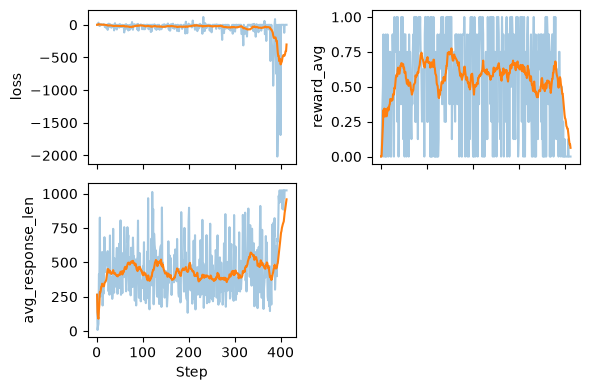

In [19]:
plot_grpo_metrics(
    "logs/rlvr_grpo_original_no_kl_metrics.csv",
    columns=["loss", "reward_avg", "avg_response_len", "eval_acc"],
    window_fraction=0.05,
)


ch06_rlvr_grpo_original_no_kl_metrics.csv: 25.1 KB
ch06_rlvr_grpo_original_no_kl_metrics.txt: 43.7 KB


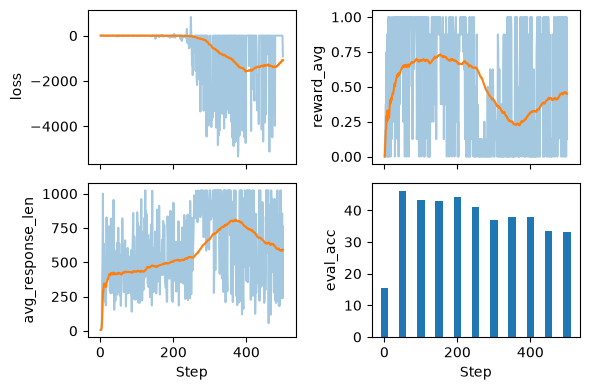

In [15]:
# From Sebastian Raschka. Build_a_Reasoning_Model_(From_Scratch) repo

download_from_github("ch07/02_logs/ch06_rlvr_grpo_original_no_kl_metrics.csv")
download_from_github("ch07/02_logs/ch06_rlvr_grpo_original_no_kl_metrics.txt")

plot_grpo_metrics(
    "ch06_rlvr_grpo_original_no_kl_metrics.csv",
    columns=["loss", "reward_avg", "avg_response_len", "eval_acc"],
)

In [20]:
import torch

def compute_advantage_stats(rewards_list):

    rewards = torch.tensor(rewards_list)#1
    advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)


    adv_avg = advantages.mean().item()#2
    adv_std = advantages.std().item()

    return advantages, adv_avg, adv_std

adv, adv_avg, adv_std = compute_advantage_stats([1., 1., 0., 0.])
print(f"Advantages: {adv}")
print(f"Advantage mean = {adv_avg:.4f}, std = {adv_std:.4f}")


Advantages: tensor([ 0.8659,  0.8659, -0.8659, -0.8659])
Advantage mean = 0.0000, std = 0.9998


### Entropy

In [21]:
logits = torch.tensor([
    0.6667, -2.0000,  1.3333, -0.0000, -0.6667,  2.0000, -1.3333
])

logprobs = torch.log_softmax(logits, dim=-1)
print("All token logprobs:", logprobs)

selected_token = torch.argmax(logprobs)
selected = logprobs[selected_token]
print("Selected token ID:", selected_token)
print("Selected token logprob:", selected)


All token logprobs: tensor([-2.0442, -4.7109, -1.3776, -2.7109, -3.3776, -0.7109, -4.0442])
Selected token ID: tensor(5)
Selected token logprob: tensor(-0.7109)


As a rough rule of thumb:
- Very low entropy (≈ 0–0.5) means that one token dominates the distribution. The model is highly confident and behaves almost deterministically.
- Moderate entropy (≈ 1–2) means the probabilities are shared across a reasonably small set of tokens, which is typical during stable training.
- High entropy (approaching [log × vocabulary size]; here, log(7) = 1.9459) means the probabilities are spread across many tokens. In this case, the model is highly uncertain and behaves almost randomly.

Sebastian Raschka. Build_a_Reasoning_Model_(From_Scratch) (Function). Kindle Edition.

In [22]:
probs = torch.softmax(logits, dim=-1)
logprobs = torch.log_softmax(logits, dim=-1)
entropy = torch.sum(-(probs * logprobs))

print("Probs:", probs)
print("Entropy:", entropy)


Probs: tensor([0.1295, 0.0090, 0.2522, 0.0665, 0.0341, 0.4912, 0.0175])
Entropy: tensor(1.3700)


7_3_plus_tracking_metrics.csv: 39.0 KB


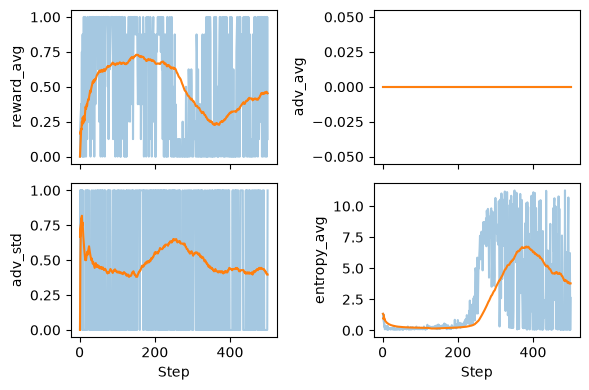

In [23]:
# Download training run results with entropy statistics
download_from_github(
    "ch07/02_logs/7_3_plus_tracking_metrics.csv"
)
plot_grpo_metrics(
    "7_3_plus_tracking_metrics.csv",
    columns=["reward_avg", "adv_avg", "adv_std", "entropy_avg"]
)

Next, let’s look at the entropy. Early in training, the entropy is relatively low and fairly flat, which indicates that the model behaves in a largely deterministic way. Increasing the sampling temperature would lead to more diverse rollouts, although it does not change the underlying entropy of the model itself.

Later in training, after roughly step 200, entropy increases quite noticeably. This means the next-token probabilities are more spread out and the model behaves more randomly. Very low entropy can also be a sign of collapse, where the model repeatedly produces the same or very similar outputs. In this run, the entropy and the increasing average reward and non-vanishing advantage standard deviation suggest somewhat healthy exploration rather than collapse. This is also consistent with the earlier MATH-500 evaluation accuracy, which stays in the 30%–40% range. That’s not great, but it is not near zero.

The main takeaway here is that each metric tells a slightly different part of the story, and they are most useful when considered together and in context.

Sebastian Raschka. Build_a_Reasoning_Model_(From_Scratch) (Function). Kindle Edition.

## Stabilizing Sequence-level GRPO using Clipped Policy Rations
### Computing Clipped Policy Ratios

In [25]:
new_logps = torch.tensor([-7.9243, -20.1546, -16.6130, -23.3677])

old_logps = torch.tensor([
    -10.9243,   # -7.9243
    -20.3546,   # -20.1546
    -14.6130,   # -16.6130
    -23.3677,   # -23.3677
])

log_ratio = new_logps - old_logps
ratio = torch.exp(log_ratio)
clip_eps = 10.0
clipped_ratio = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps)

print("Ratio:        ", ratio)
print("Clipped ratio:", clipped_ratio)


Ratio:         tensor([20.0855,  1.2214,  0.1353,  1.0000])
Clipped ratio: tensor([11.0000,  1.2214,  0.1353,  1.0000])


In [26]:
# Example data
rewards = torch.tensor([1., 1., 0., 0.])
advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)

# Compute clipped policy gradient loss
adv = advantages.detach()
unclipped = ratio * adv
clipped = clipped_ratio * adv

obj = torch.minimum(unclipped, clipped)

clipped_pg_loss = -torch.mean(obj)
policy_ratio = torch.mean(ratio)

print(f"Clipped Policy Gradient Loss: {clipped_pg_loss:.4f}")
print(f"Policy Ratio:                  {policy_ratio:.4f}")

Clipped Policy Gradient Loss: -2.3998
Policy Ratio:                  5.6106


### Training with Clipped Policy ratios

In [27]:
download_from_github(
    "ch07/03_rlvr_grpo_scripts_advanced/7_4_plus_clip_ratio.py"
)


7_4_plus_clip_ratio.py: 19.0 KB


7_4_plus_clip_ratio_metrics.csv: 42.7 KB


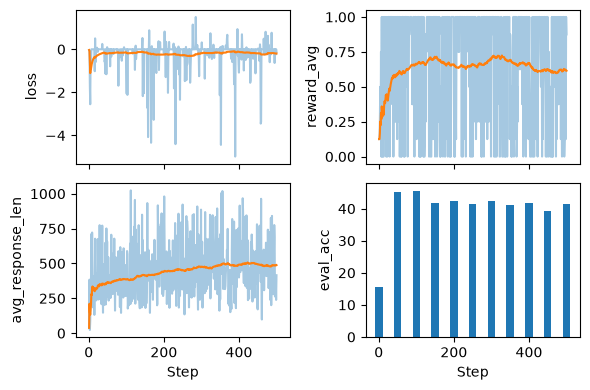

In [28]:
# Run training
# !uv run 7_4_plus_clip_ratio.py --steps 500  --max_new_tokens 1024

# Or download results
download_from_github(
    "ch07/02_logs/7_4_plus_clip_ratio_metrics.csv"
)
plot_grpo_metrics(
    "7_4_plus_clip_ratio_metrics.csv",
    columns=["loss", "reward_avg", "avg_response_len", "eval_acc"]
)


## Controlling how much the model changes with a KL term

In [32]:
import copy

kl_coeff = 0.0

if kl_coeff:
    ref_model = copy.deepcopy(model).to(device)
    ref_model.eval()
    for p in ref_model.parameters():
        p.requires_grad = False
else:
    ref_model = None

### Training with a KL Loss Term

In [30]:
# Script to run training
download_from_github(
    "ch07/03_rlvr_grpo_scripts_advanced/7_5_plus_kl.py"
)

# Log files
download_from_github(
    "ch07/02_logs/"
    "7_5_plus_kl_metrics.csv"
)


7_5_plus_kl.py: 20.7 KB
7_5_plus_kl_metrics.csv: 48.8 KB


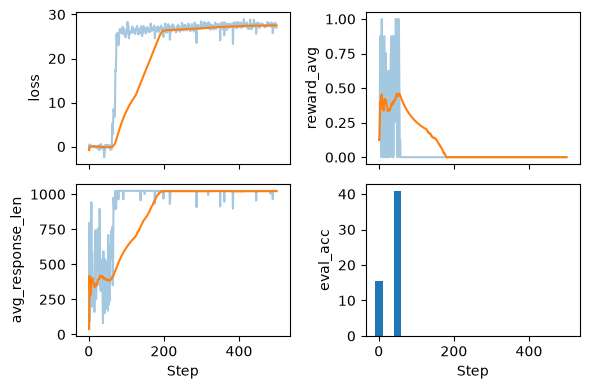

In [33]:
# Run training
# !uv run 7_5_plus_kl.py --steps 500 --max_new_tokens 1024

# Plot metrics
plot_grpo_metrics(
    "7_5_plus_kl_metrics.csv",
    columns=["loss", "reward_avg", "avg_response_len", "eval_acc"]
)

Improving training stability with a KL term Alternatively, instead of removing the KL term, there are several ways to improve training stability. First, we can reduce kl_coeff from 0.02 to a smaller value (for example, 0.001) to weaken the KL penalty, although this was not sufficient in my experiments.

Since we saw that the response length keeps growing until it hits the maximum, another option is to length normalize the sequence logprobs by dividing by the number of generated tokens, which approximates average per-token logprobs. This could reduce the incentive to increase response length to accumulate larger absolute logprob differences.

A third option is to use a reweighted KL term based on importance sampling, as proposed by DeepSeek-V3.2. This matters because the rollouts are generated by the old policy, while the KL term is intended to constrain the current policy relative to the reference policy. Instead of using

```python
kl_loss = kl_coeff * torch.mean(logps - ref_logps)
```

we could use

```python
kl_loss = (
    kl_coeff * torch.mean(torch.exp(new_logps - old_logps)
    * (new_logps - ref_logps)
)
```

Here, the importance weight torch.exp(new_logps - old_logps) corrects for rollouts being generated by the old policy, and it downweights samples that the current policy would rarely produce and upweights those it would.

Finally, we could add a small format reward to prevent advantages from collapsing to zero (we will revisit format rewards in the next section). That said, for math data, a common recommendation is to omit the KL term altogether (e.g., Dr. GRPO, Olmo 3, and DeepSeek-V3.2), which also simplifies the code and reduces resource requirements, since we don’t have to keep an additional reference model in memory.

Sebastian Raschka. Build_a_Reasoning_Model_(From_Scratch) (Function). Kindle Edition.

## Adding an Explicit Format Reward
### Using <think> Tokens

In [34]:
from mi.gpu import get_device
from mi.lm.model_loader import load_model_and_tokenizer

device = get_device()
model, tokenizer_base = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)

Using Apple Silicon GPU (MPS)
✓ downloads/qwen3-0.6B-base.pth already up-to-date


In [35]:
print(tokenizer_base.encode("<think>"))

[13708, 766, 29]


In [36]:
tokenizer_base._tok.add_special_tokens(
    ["<tool_response>", "</tool_response>", "<think>", "</think>"]
)

4

In [37]:
print(tokenizer_base.encode("<think>"))
print(tokenizer_base.encode("</think>"))

[151667]
[151668]


In [38]:
print(f"Vocab size: {model.tok_emb.weight.shape[0]}")

Vocab size: 151936


In [39]:
from reasoning_from_scratch.qwen3 import Qwen3Tokenizer, download_qwen3_small

download_qwen3_small(
    kind="reasoning", tokenizer_only=True, out_dir="qwen3"
)

tokenizer_path = Path("qwen3") / "tokenizer-reasoning.json"
tokenizer = Qwen3Tokenizer(tokenizer_file_path=tokenizer_path)

tokenizer-reasoning.json: 100% (10 MiB / 10 MiB)


In [40]:
print(tokenizer.encode("<think>"))
print(tokenizer.encode("</think>"))

[151667]
[151668]


In [41]:
from mi.lm.scoring import reward_format

prompt = "Calculate ..."
rollout = "Let's ... <think> ... </think> ..."
token_ids = tokenizer.encode(prompt + rollout)
reward_format(
    token_ids=torch.tensor(token_ids),
    prompt_len=len(tokenizer.encode(prompt))
)

1.0

### Training a Model to Emit <think> Tokens

In [42]:
download_from_github(
    "ch07/03_rlvr_grpo_scripts_advanced/7_6_plus_format_reward.py"
)
download_from_github(
    "ch07/02_logs/7_6_plus_format_reward_metrics.csv"
)

7_6_plus_format_reward.py: 23.1 KB
7_6_plus_format_reward_metrics.csv: 51.7 KB


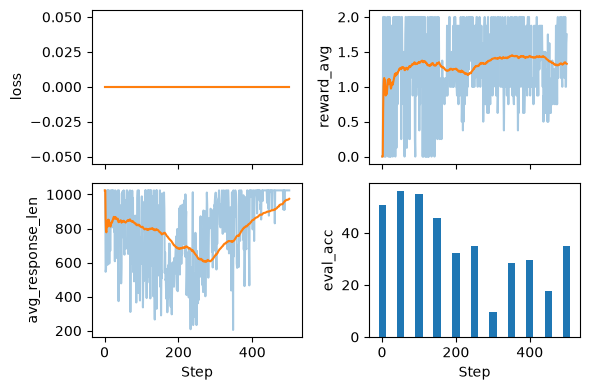

In [43]:
# !uv run 7_6_plus_format_reward.py --steps 500 --max_new_tokens 1024
plot_grpo_metrics(
    "7_6_plus_format_reward_metrics.csv",
    columns=["loss", "reward_avg", "avg_response_len", "eval_acc"]
)

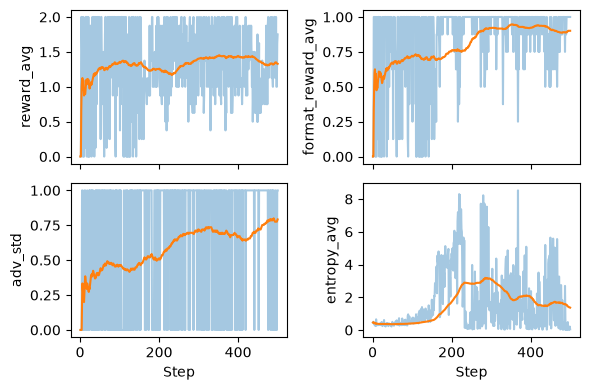

In [44]:
plot_grpo_metrics(
    "7_6_plus_format_reward_metrics.csv",
    columns=["reward_avg", "format_reward_avg", "adv_std", "entropy_avg"],
)

### Final GRPO Modifications, Tips, and Tricks
1. Filter out zero-gradient examples (DAPO): Skip prompts where all sampled responses receive the same reward, because these groups produce no useful advantage signal.
2. Use active sampling (DAPO): Oversample or prioritize prompts that produce a mix of correct and incorrect responses, because these provide a stronger learning signal.
3. Switch from sequence-level to token-level loss (DAPO): Compute the loss over individual tokens rather than whole responses, which can reduce length-related bias.
4. Omit the KL loss term (DAPO and Dr. GRPO): Remove the KL penalty when it hurts stability or performance, especially in math reasoning settings.
5. Use a larger clipping range (DAPO): Relax the clipping threshold so the policy can make larger updates when the reward signal is reliable.
6. Truncate importance-sampling ratios (verl): Cap very large importance weights so a few off-policy samples cannot dominate the update.
7. Remove standard-deviation normalization of advantages (Dr. GRPO): Normalize rewards relative to the group mean but avoid dividing by the reward standard deviation.
8. Tune the KL strength by domain (DeepSeek-V3.2): Use different KL coefficients for different data types, including zero KL for math tasks.
9. Reweight the KL term with importance sampling (DeepSeek-V3.2): Correct the KL estimate when rollouts are sampled from an older policy rather than the current policy.
10. Mask unsuitable off-policy sequences (DeepSeek-V3.2): Exclude rollout sequences that are too unlikely under the current policy.
11. Preserve the sampling mask for top-p or top-k sampling (DeepSeek-V3.2): Compute probabilities only over the token set that was actually available during sampling.
12. Keep the original GRPO advantage normalization (DeepSeek-V3.2): Retain the standard group-based advantage normalization when it works well empirically.
13. Normalize each reward component before aggregation (GDPO): Normalize different reward types separately before combining them into a total reward.
14. Apply sequence-level importance sampling and clipping (GSPO): Correct and clip updates at the whole-sequence level instead of only at the token level.
15. Clip importance-sampling weights rather than token updates (CISPO): Limit the importance weights directly, so off-policy corrections remain stable.

Sebastian Raschka. Build_a_Reasoning_Model_(From_Scratch) (Function). Kindle Edition.